# Debugger da transferencia de reflexoes

Este notebook investiga ARC e GSM8K em 30 itens de teste por dataset, usando `phi4-mini` e `llama3-8b` (o modelo referido como ollama3.1:8b no pedido). As reflexoes do professor `gpt-5-petrobras` sao carregadas de `results/reflections`.

Resultados persistidos sao reportados como observados. Variacoes de `k`, limiar de similaridade e prompt so recebem acuracia depois que a rotina opcional de inferencia for executada.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]='5'

In [2]:
from pathlib import Path
import ast
import json
import sys
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATASETS = ('arc', 'gsm8k')
STUDENTS = ('phi4-mini', 'llama3-8b','mistral-7b')
TEACHER = 'gpt-5-petrobras'
DEPTHS = ('simple', 'complex')
N_ITEMS = 50
K_VALUES = (1,2,3, 5)
THRESHOLDS = (None,0.50,0.60, 0.70, 0.80, 0.90)
print('ROOT =', ROOT)

ROOT = /home/rodrigo.flexa/Reflection-MCQ


## 1. Auditoria rapida do codigo e dos dados

A auditoria compila os modulos do `rmcq`, verifica o invariante de rotulos e confere se baseline, reflexoes e avaliacoes usam os mesmos UIDs. Ela tambem explicita lacunas da grade, em vez de trata-las como acuracia zero.

In [3]:
def read_jsonl(path):
    if not path.exists():
        return []
    with path.open(encoding='utf-8') as fh:
        return [json.loads(line) for line in fh if line.strip()]

audit = []
for path in sorted((ROOT / 'rmcq').rglob('*.py')):
    try:
        ast.parse(path.read_text(encoding='utf-8'))
        audit.append({'arquivo': str(path.relative_to(ROOT)), 'status': 'OK'})
    except SyntaxError as exc:
        audit.append({'arquivo': str(path.relative_to(ROOT)), 'status': f'ERRO: {exc}'})

schema_checks = []
for dataset in DATASETS:
    for split in ('train', 'test'):
        rows = read_jsonl(ROOT / 'data' / 'splits' / dataset / f'{split}.jsonl')
        bad = []
        for row in rows:
            labels = [c.get('label') for c in row.get('choices', [])]
            expected = [chr(65 + i) for i in range(len(labels))]
            if labels != expected or row.get('answerKey') not in labels:
                bad.append(row.get('uid'))
        schema_checks.append({'dataset': dataset, 'split': split, 'n': len(rows), 'rotulos_invalidos': len(bad), 'exemplos': bad[:3]})

display(pd.DataFrame(audit))
display(pd.DataFrame(schema_checks))
print('Lacuna esperada: os resultados persistidos desta rodada so contem k=3; k=1 e k=5 serao gerados pela rotina opcional.')

,arquivo,status
0,rmcq/__init__.py,OK
1,rmcq/__main__.py,OK
2,rmcq/backends/__init__.py,OK
3,rmcq/backends/azure.py,OK
4,rmcq/backends/base.py,OK
5,rmcq/backends/hf.py,OK
6,rmcq/backends/stub.py,OK
7,rmcq/backends/vllm_backend.py,OK
8,rmcq/cli.py,OK
9,rmcq/common.py,OK


,dataset,split,n,rotulos_invalidos,exemplos
0,arc,train,286,0,[]
1,arc,test,1171,0,[]
2,gsm8k,train,366,0,[]
3,gsm8k,test,1319,0,[]


Lacuna esperada: os resultados persistidos desta rodada so contem k=3; k=1 e k=5 serao gerados pela rotina opcional.


In [4]:
def load_map(path):
    return {row['uid']: row for row in read_jsonl(path)}

def first_items(dataset, n=N_ITEMS):
    items = load_map(ROOT / 'data' / 'splits' / dataset / 'test.jsonl') 
    return list(items.values())[:n]

inventory = []
for student in STUDENTS:
    for dataset in DATASETS:
        base_path = ROOT / 'results' / 'baseline' / student / f'{dataset}_test.jsonl'
        base = load_map(base_path)
        selected = {item['uid'] for item in first_items(dataset)}
        for depth in DEPTHS:
            refl_path = ROOT / 'results' / 'reflections' / f'{student}__{TEACHER}__{depth}' / f'{dataset}.jsonl'
            eval_path = ROOT / 'results' / 'eval' / f'{student}__{TEACHER}__{depth}__k3' / f'{dataset}.jsonl'
            refl = load_map(refl_path)
            ev = load_map(eval_path)
            inventory.append({
                'student': student, 'dataset': dataset, 'depth': depth,
                'baseline_30': len(selected & base.keys()),
                'reflections': len(refl), 'eval_k3': len(selected & ev.keys()),
                'reflexoes_arquivo': refl_path.exists(), 'eval_arquivo': eval_path.exists(),
            })
display(pd.DataFrame(inventory))

,student,dataset,depth,baseline_30,reflections,eval_k3,reflexoes_arquivo,eval_arquivo
0,phi4-mini,arc,simple,50,286,50,True,True
1,phi4-mini,arc,complex,50,286,50,True,True
2,phi4-mini,gsm8k,simple,50,366,50,True,True
3,phi4-mini,gsm8k,complex,50,366,50,True,True
4,llama3-8b,arc,simple,50,286,50,True,True
5,llama3-8b,arc,complex,50,286,50,True,True
6,llama3-8b,gsm8k,simple,50,366,50,True,True
7,llama3-8b,gsm8k,complex,50,366,50,True,True
8,mistral-7b,arc,simple,50,286,50,True,True
9,mistral-7b,arc,complex,50,286,50,True,True


## 2. Tabela observada: baseline contra k=3

`SUCESSO` significa acuracia com reflexao estritamente maior que o baseline no mesmo subconjunto de 30 itens. Empate e `FRACASSO`, conforme o criterio pedido.

In [5]:
def acc(rows):
    return sum(bool(r.get('is_correct')) for r in rows) / len(rows) if rows else np.nan

observed = []
for student in STUDENTS:
    for dataset in DATASETS:
        selected = [item['uid'] for item in first_items(dataset)]
        base = load_map(ROOT / 'results' / 'baseline' / student / f'{dataset}_test.jsonl')
        base_rows = [base[uid] for uid in selected if uid in base]
        base_acc = acc(base_rows)
        for depth in DEPTHS:
            ev = load_map(ROOT / 'results' / 'eval' / f'{student}__{TEACHER}__{depth}__k3' / f'{dataset}.jsonl')
            ev_rows = [ev[uid] for uid in selected if uid in ev]
            eval_acc = acc(ev_rows)
            sim = [((r.get('extra') or {}).get('top1_similarity')) for r in ev_rows]
            sim = [x for x in sim if x is not None]
            observed.append({
                'dataset': dataset, 'student': student, 'teacher': TEACHER,
                'prompt_variant': 'frozen_observed', 'depth': depth, 'k': 3,
                'similarity_threshold': None, 'n': len(ev_rows),
                'baseline_accuracy': base_acc, 'reflection_accuracy': eval_acc,
                'delta': eval_acc - base_acc if ev_rows else np.nan,
                'status': 'SUCESSO' if ev_rows and eval_acc > base_acc else 'FRACASSO',
                'mean_top1_similarity': np.mean(sim) if sim else np.nan,
            })
observed_df = pd.DataFrame(observed)
display(observed_df.style.format({'baseline_accuracy': '{:.3f}', 'reflection_accuracy': '{:.3f}', 'delta': '{:+.3f}', 'mean_top1_similarity': '{:.3f}'}))

,dataset,student,teacher,prompt_variant,depth,k,similarity_threshold,n,baseline_accuracy,reflection_accuracy,delta,status,mean_top1_similarity
0,arc,phi4-mini,gpt-5-petrobras,frozen_observed,simple,3,None,50,0.900,0.840,-0.060,FRACASSO,0.653
1,arc,phi4-mini,gpt-5-petrobras,frozen_observed,complex,3,None,50,0.900,0.760,-0.140,FRACASSO,0.653
2,gsm8k,phi4-mini,gpt-5-petrobras,frozen_observed,simple,3,None,50,0.860,0.800,-0.060,FRACASSO,0.687
3,gsm8k,phi4-mini,gpt-5-petrobras,frozen_observed,complex,3,None,50,0.860,0.780,-0.080,FRACASSO,0.687
4,arc,llama3-8b,gpt-5-petrobras,frozen_observed,simple,3,None,50,0.840,0.700,-0.140,FRACASSO,0.653
5,arc,llama3-8b,gpt-5-petrobras,frozen_observed,complex,3,None,50,0.840,0.720,-0.120,FRACASSO,0.653
6,gsm8k,llama3-8b,gpt-5-petrobras,frozen_observed,simple,3,None,50,0.820,0.760,-0.060,FRACASSO,0.687
7,gsm8k,llama3-8b,gpt-5-petrobras,frozen_observed,complex,3,None,50,0.820,0.540,-0.280,FRACASSO,0.687
8,arc,mistral-7b,gpt-5-petrobras,frozen_observed,simple,3,None,50,0.780,0.240,-0.540,FRACASSO,0.653
9,arc,mistral-7b,gpt-5-petrobras,frozen_observed,complex,3,None,50,0.780,0.340,-0.440,FRACASSO,0.653


## 3. Versao do prompt, similaridade, k e Key Takeaway

A inferencia da grade (k, limiar de similaridade, com/sem Key Takeaway) roda fora do notebook, em `scripts/run_debugger_grid.py`, pensado para tmux/nohup e resumivel por linha (fsync a cada lote, entao uma queda do servidor so perde o lote em voo).

A variante `takeaway=with` pede ao professor (`gpt-5-petrobras`) um resumo de uma linha ("Takeaway: ...") de cada reflexao ja escrita, e concatena esse resumo a ela antes de injetar no prompt do aluno. Os takeaways sao gerados uma vez por (aluno, professor, profundidade, dataset) e cacheados em `notebooks/debugger_results/takeaways/`.

Rodar dentro de uma sessao tmux:

```bash
source venv/bin/activate
python scripts/run_debugger_grid.py --backend hf
# ou, se o ambiente vLLM estiver validado:
python scripts/run_debugger_grid.py --backend vllm --cuda-devices 5
```

`--prompt-version` e o eixo novo da grade. `v1` e o layout antigo: as licoes abriam o prompt, antes de o modelo saber que ia responder uma questao de multipla escolha, e a instrucao de formato ficava a ~2.000 tokens do inicio. `v2` foi reescrito para phi4-mini e llama3-8b — enquadramento primeiro, `<notes>` delimitadas com o enunciado de origem (com contexto), questao e formato de saida por ultimo, reflexao cortada em 120 palavras **pela cabeca** (a parte que transfere fica na cauda) e letras de alternativa neutralizadas (`"you selected D"` -> `"you selected [letter]"`, porque 50% das reflexoes `complex` citam uma letra que vem de OUTRA questao).

```bash
# compara os dois layouts no mesmo subconjunto
python scripts/run_debugger_grid.py --backend vllm --cuda-devices 5 --prompt-version v1
python scripts/run_debugger_grid.py --backend vllm --cuda-devices 5 --prompt-version v2
```

Os resultados ficam em `notebooks/debugger_results/responses/{student}/{dataset}.jsonl`. A celula abaixo so LE esses arquivos; ela nao faz inferencia. Linhas gravadas antes deste eixo existir sao rotuladas `prompt_version='v1'` na leitura, entao as duas versoes nunca caem na mesma media.

In [ ]:
RESULTS_DIR = ROOT / 'notebooks' / 'debugger_results' / 'responses'

def load_grid_results(students=STUDENTS, datasets=DATASETS):
    frames = []
    for student in students:
        for dataset in datasets:
            path = RESULTS_DIR / student / f'{dataset}.jsonl'
            rows = read_jsonl(path) if path.exists() else []
            if rows:
                frames.append(pd.DataFrame(rows))
            else:
                print(f'sem resultados ainda: {path}')
    if not frames:
        return pd.DataFrame()
    result = pd.concat(frames, ignore_index=True)
    # Linhas gravadas antes de scripts/run_debugger_grid.py ganhar --prompt-version
    # sao do layout antigo. Sem esta coluna, v1 e v2 cairiam no mesmo grupo e a
    # media esconderia justamente o efeito que queremos medir.
    if 'prompt_version' not in result.columns:
        result['prompt_version'] = 'v1'
    result['prompt_version'] = result['prompt_version'].fillna('v1')
    return result

def summarize_grid(result):
    if result.empty:
        return result
    base = {}
    for student in STUDENTS:
        for dataset in DATASETS:
            rows = load_map(ROOT / 'results' / 'baseline' / student / f'{dataset}_test.jsonl')
            selected = {item['uid'] for item in first_items(dataset)}
            base[(student, dataset)] = acc([rows[u] for u in selected if u in rows])
    grouped = result.groupby(['dataset', 'student', 'teacher', 'depth', 'k', 'similarity_threshold', 'takeaway', 'prompt_version'], dropna=False)
    summary = grouped['is_correct'].agg(n='size', reflection_accuracy='mean').reset_index()
    summary['baseline_accuracy'] = [base[(r.student, r.dataset)] for r in summary.itertuples()]
    summary['delta'] = summary['reflection_accuracy'] - summary['baseline_accuracy']
    summary['status'] = np.where(summary['delta'] > 0, 'SUCESSO', 'FRACASSO')
    return summary.sort_values(['dataset', 'student', 'delta'], ascending=[True, True, False])

grid = load_grid_results()
if grid.empty:
    print('Nenhum resultado encontrado ainda. Rode scripts/run_debugger_grid.py primeiro.')
else:
    display(summarize_grid(grid))

## 4. Diagnostico de viradas

Depois de executar a grade, esta celula mostra quais configuracoes corrigem erros e quais transformam acertos em erros. Isso ajuda a distinguir reflexao util de uma mudanca aleatoria de resposta.

In [ ]:
def flip_report(result):
    rows = []
    for key, group in result.groupby(['dataset', 'student', 'depth', 'k', 'similarity_threshold', 'takeaway', 'prompt_version'], dropna=False):
        base = load_map(ROOT / 'results' / 'baseline' / key[1] / f'{key[0]}_test.jsonl')
        shared = group[group.uid.isin(base)]
        wrong_to_right = sum((not bool(base[r.uid].get('is_correct'))) and bool(r.is_correct) for r in shared.itertuples())
        right_to_wrong = sum(bool(base[r.uid].get('is_correct')) and (not bool(r.is_correct)) for r in shared.itertuples())
        rows.append(dict(zip(['dataset', 'student', 'depth', 'k', 'similarity_threshold', 'takeaway', 'prompt_version'], key), n=len(shared), wrong_to_right=wrong_to_right, right_to_wrong=right_to_wrong, utility=(wrong_to_right-right_to_wrong)/len(shared) if len(shared) else np.nan))
    return pd.DataFrame(rows).sort_values('utility', ascending=False)

if 'grid' in globals() and not grid.empty:
    display(flip_report(grid).head(20))
else:
    print('Execute scripts/run_debugger_grid.py primeiro para obter o relatorio de viradas.')

## 5. Efeito dos parametros da grade

Os graficos comparam a acuracia obtida com reflexoes com o **baseline**: a acuracia do mesmo aluno e dataset sem reflexoes. Em cada grafico, linhas cheias sao configuracoes com reflexoes e linhas tracejadas sao o baseline correspondente. As profundidades `simple` e `complex` aparecem como linhas separadas. Configuracoes ainda nao executadas ficam fora das tabelas e graficos.

In [ ]:
import matplotlib.pyplot as plt

def baseline_by_group():
    values = {}
    for student in STUDENTS:
        for dataset in DATASETS:
            path = ROOT / 'results' / 'baseline' / student / f'{dataset}_test.jsonl'
            rows = load_map(path)
            selected = [item['uid'] for item in first_items(dataset)]
            values[(student, dataset)] = acc([rows[uid] for uid in selected if uid in rows])
    return values

def add_baseline_delta(frame):
    result = frame.copy()
    baselines = baseline_by_group()
    result['baseline_accuracy'] = [baselines.get((row.student, row.dataset), np.nan) for row in result.itertuples()]
    result['ganho_vs_baseline'] = result['reflection_accuracy'] - result['baseline_accuracy']
    return result

def parameter_summary(frame, parameter):
    columns = ['dataset', 'student', 'depth', parameter]
    if parameter != 'prompt_version':
        columns.insert(3, 'prompt_version')
    summary = (
        frame.groupby(columns, dropna=False)['is_correct']
        .agg(n='size', reflection_accuracy='mean')
        .reset_index()
    )
    return add_baseline_delta(summary)

def format_threshold(value):
    return 'sem filtro' if pd.isna(value) else f'{float(value):.2f}'

if grid.empty:
    print('Nenhum resultado da grade disponivel ainda.')
else:
    grid_analysis = grid.copy()
    grid_analysis['is_correct'] = grid_analysis['is_correct'].astype(bool)
    grid_analysis = add_baseline_delta(
        grid_analysis.groupby(
            ['dataset', 'student', 'teacher', 'depth', 'k',
             'similarity_threshold', 'takeaway', 'prompt_version'], dropna=False
        )['is_correct'].agg(n='size', reflection_accuracy='mean').reset_index()
    )
    grid_analysis['threshold_label'] = grid_analysis['similarity_threshold'].map(format_threshold)

    ranking = grid_analysis.sort_values(
        ['ganho_vs_baseline', 'reflection_accuracy', 'n'], ascending=False
    )
    print('Melhores configuracoes: ganho positivo significa que a reflexao superou o baseline.')
    display(ranking.head(15)[[
        'dataset', 'student', 'depth', 'prompt_version', 'k', 'threshold_label', 'takeaway',
        'n', 'baseline_accuracy', 'reflection_accuracy', 'ganho_vs_baseline'
    ]].style.format({
        'baseline_accuracy': '{:.3f}', 'reflection_accuracy': '{:.3f}',
        'ganho_vs_baseline': '{:+.3f}'
    }))
    print('Piores configuracoes: perda negativa significa que a reflexao ficou abaixo do baseline.')
    display(ranking.tail(15).sort_values('ganho_vs_baseline')[[
        'dataset', 'student', 'depth', 'prompt_version', 'k', 'threshold_label', 'takeaway',
        'n', 'baseline_accuracy', 'reflection_accuracy', 'ganho_vs_baseline'
    ]].style.format({
        'baseline_accuracy': '{:.3f}', 'reflection_accuracy': '{:.3f}',
        'ganho_vs_baseline': '{:+.3f}'
    }))

    parameter_tables = {}
    for parameter in ('k', 'similarity_threshold', 'takeaway', 'prompt_version'):
        table = parameter_summary(grid, parameter)
        table['value'] = (
            table[parameter].map(format_threshold)
            if parameter == 'similarity_threshold' else table[parameter].astype(str)
        )
        parameter_tables[parameter] = table

    for parameter in ('k', 'similarity_threshold'):
        table = parameter_tables[parameter].copy()
        table = table.sort_values(['dataset', 'student', 'depth', parameter])
        table['mudanca_anterior'] = table.groupby(
            ['dataset', 'student', 'depth', 'prompt_version']
        )['reflection_accuracy'].diff()
        print(f'Mudanca ao aumentar {parameter}:')
        display(table.dropna(subset=['mudanca_anterior']).sort_values(
            'mudanca_anterior', ascending=False
        ).head(20)[[
            'dataset', 'student', 'depth', 'prompt_version', 'value', 'n',
            'reflection_accuracy', 'mudanca_anterior'
        ]].style.format({
            'reflection_accuracy': '{:.3f}',
            'mudanca_anterior': '{:+.3f}'
        }))

### 5.1 ARC

Cada coluna representa um parametro. A linha superior usa reflexoes `simple` e a inferior reflexoes `complex`. Linhas cheias mostram a acuracia com reflexoes; tracejadas, o baseline do mesmo aluno.

In [ ]:
def plot_dataset_parameters(dataset_name):
    plot_specs = [
        ('k', 'k', 'Acuracia por k'),
        ('similarity_threshold', 'value', 'Acuracia por limiar'),
        ('takeaway', 'takeaway', 'Acuracia com/sem takeaway'),
        ('prompt_version', 'value', 'Acuracia por versao do prompt'),
    ]
    colors = {student: f'C{index}' for index, student in enumerate(STUDENTS)}
    fig, axes = plt.subplots(2, len(plot_specs), figsize=(5.7 * len(plot_specs), 8), constrained_layout=True)
    for row, depth_name in enumerate(('simple', 'complex')):
        for axis, (parameter, x_column, title) in zip(axes[row], plot_specs):
            table = parameter_tables[parameter]
            table = table[(table['dataset'] == dataset_name) & (table['depth'] == depth_name)]
            for student_name, group in table.groupby('student'):
                group = group.sort_values(parameter)
                color = colors[student_name]
                axis.plot(
                    group[x_column], group['reflection_accuracy'], marker='o',
                    color=color, label=student_name
                )
                axis.axhline(
                    group['baseline_accuracy'].iloc[0], color=color,
                    linestyle='--', linewidth=1.2, alpha=0.7
                )
            axis.set_title(f'{title} - {depth_name}')
            axis.set_xlabel(parameter)
            axis.set_ylabel('acuracia')
            axis.set_ylim(0, 1)
            axis.grid(alpha=0.25)
            axis.legend(fontsize=8)
    fig.suptitle(dataset_name.upper(), fontsize=16)
    plt.show()

if not grid.empty:
    plot_dataset_parameters('arc')

### 5.2 GSM8K

A mesma leitura é aplicada separadamente ao GSM8K, sem curvas do ARC no mesmo gráfico.

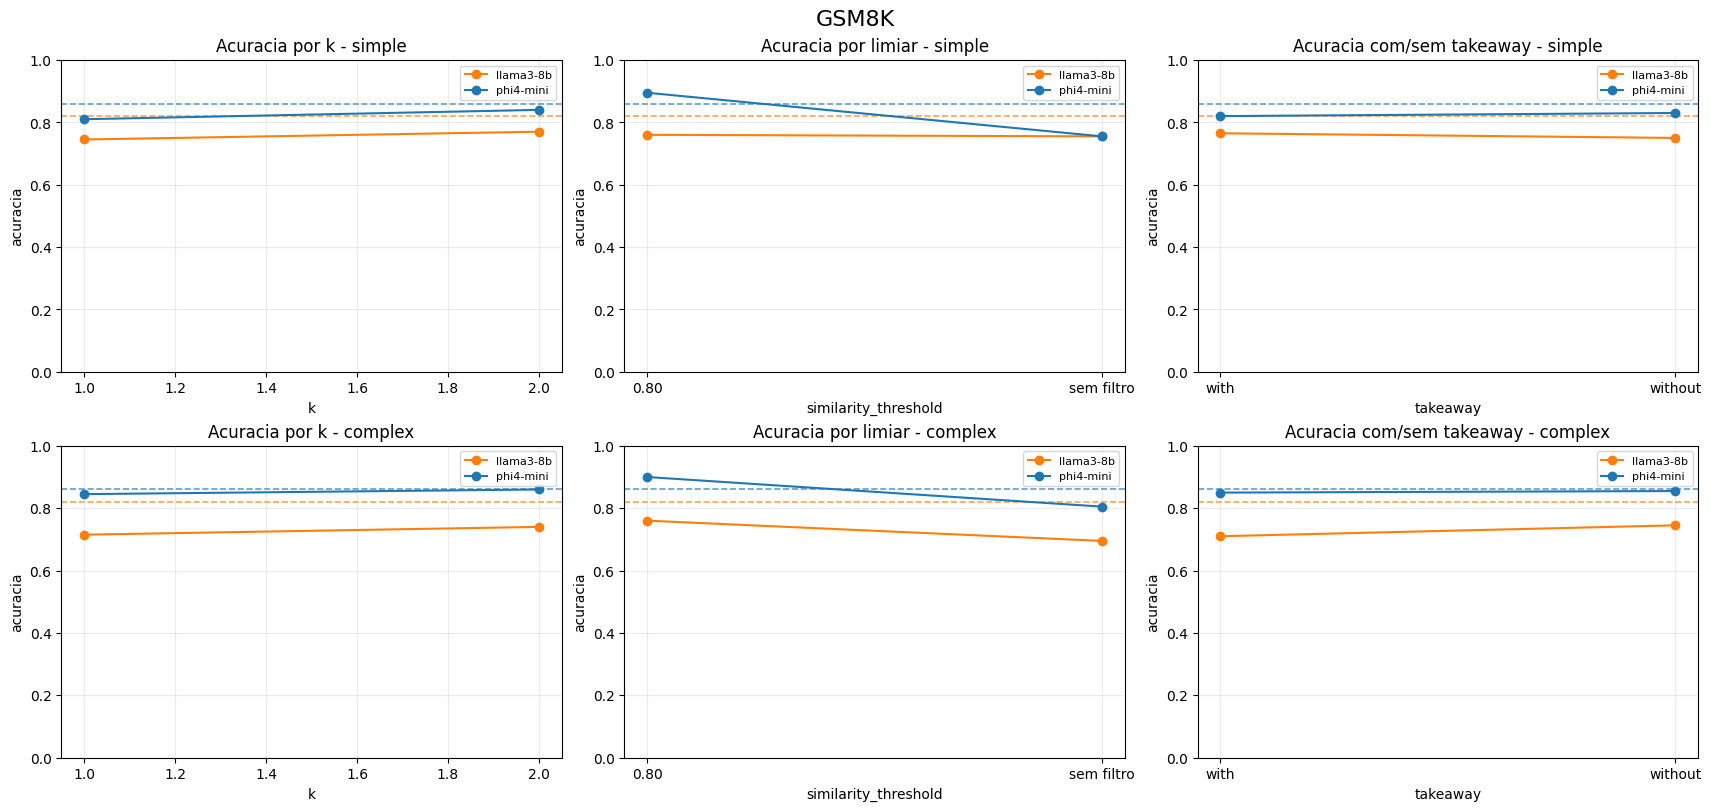

In [10]:
if not grid.empty:
    plot_dataset_parameters('gsm8k')

In [ ]:
if not grid.empty:
    print('Melhor valor agregado de cada parametro:')
    overall = []
    for parameter, label_column in (
        ('k', 'value'),
        ('similarity_threshold', 'value'),
        ('takeaway', 'value'),
        ('prompt_version', 'value'),
    ):
        table = parameter_tables[parameter].copy()
        grouped = table.groupby(label_column, dropna=False)
        winners = grouped.apply(
            lambda group: pd.Series({
                'n': group['n'].sum(),
                'reflection_accuracy': np.average(group['reflection_accuracy'], weights=group['n']),
                'ganho_vs_baseline': np.average(group['ganho_vs_baseline'], weights=group['n']),
            }),
            include_groups=False,
        ).reset_index()
        winner = winners.sort_values('ganho_vs_baseline', ascending=False).iloc[0]
        overall.append({
            'parameter': parameter, 'melhor_valor': winner[label_column],
            'n': int(winner['n']),
            'acuracia': winner['reflection_accuracy'],
            'ganho_vs_baseline': winner['ganho_vs_baseline'],
        })
    display(pd.DataFrame(overall).style.format({
        'acuracia': '{:.3f}', 'ganho_vs_baseline': '{:+.3f}'
    }))

    takeaway_pairs = (
        grid_analysis.groupby(
            ['dataset', 'student', 'depth', 'prompt_version', 'k', 'similarity_threshold', 'takeaway'],
            dropna=False,
        )['reflection_accuracy'].mean().reset_index()
        .pivot_table(
            index=['dataset', 'student', 'depth', 'prompt_version', 'k', 'similarity_threshold'],
            columns='takeaway', values='reflection_accuracy'
        )
        .dropna(subset=['with', 'without'])
    )
    if not takeaway_pairs.empty:
        takeaway_pairs['with_minus_without'] = takeaway_pairs['with'] - takeaway_pairs['without']
        print('Efeito pareado de ativar takeaway (with - without):')
        display(takeaway_pairs['with_minus_without'].describe().to_frame('diferenca'))
        print('Positivo favorece with; negativo favorece without.')